In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
# Generate sample clustering data

from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=0.60,
    random_state=0
)

In [4]:
# Number of clusters
num_clusters = 5

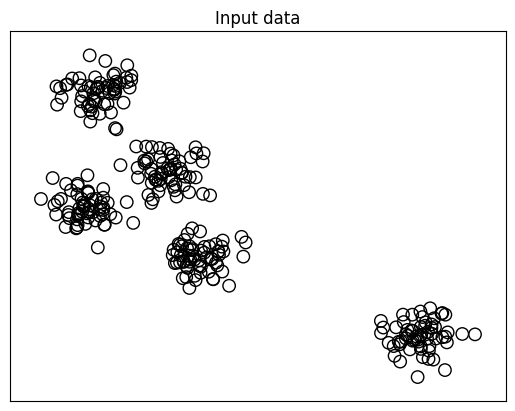

In [5]:
plt.figure()

plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=80
)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

plt.title("Input data")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xticks(())
plt.yticks(())

plt.show()

In [6]:
kmeans = KMeans(
    init="k-means++",
    n_clusters=num_clusters,
    n_init=10,
    random_state=0
)

In [7]:
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=0)

In [8]:
# Step size of the mesh
step_size = 0.01

# Define grid of points
x_values, y_values = np.meshgrid(
    np.arange(x_min, x_max, step_size),
    np.arange(y_min, y_max, step_size)
)

In [9]:
output = kmeans.predict(
    np.c_[x_values.ravel(), y_values.ravel()]
)

output = output.reshape(x_values.shape)

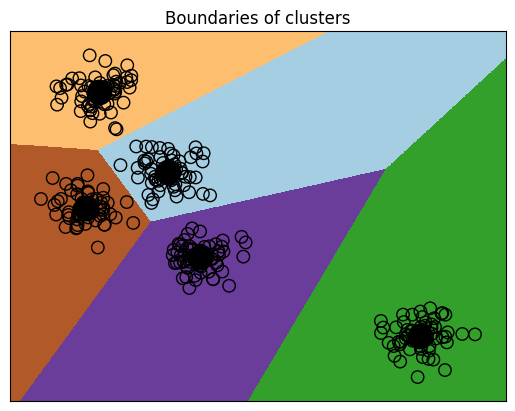

In [10]:
plt.figure()

plt.imshow(
    output,
    interpolation="nearest",
    extent=(
        x_values.min(),
        x_values.max(),
        y_values.min(),
        y_values.max()
    ),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower"
)

# Overlay input points
plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=80
)

# Plot cluster centers
cluster_centers = kmeans.cluster_centers_

plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    marker="o",
    s=210,
    linewidths=4,
    color="black",
    zorder=12,
    facecolors="black"
)

plt.title("Boundaries of clusters")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xticks(())
plt.yticks(())

plt.show()